**Importing dependencies**

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_friedman1
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler

Storing the data and the target

In [26]:
X,y=make_friedman1()

Creating the pandas dataframe for the data

In [27]:
data=pd.DataFrame(X)
data['target']=y

In [28]:
data.head()

,0,1,2,3,4,5,6,7,8,9,target
0,0.945930,0.166664,0.636636,0.664983,0.821107,0.400944,0.166232,0.736060,0.344737,0.378347,15.881532
1,0.674251,0.552043,0.616063,0.050917,0.779088,0.194037,0.099966,0.953985,0.210510,0.739795,13.878992
2,0.938255,0.578049,0.198870,0.828977,0.168101,0.285742,0.742395,0.773211,0.569874,0.617059,20.855462
3,0.130796,0.508374,0.738618,0.299635,0.660277,0.827180,0.455873,0.736141,0.364674,0.570609,9.510309
4,0.581847,0.420385,0.849355,0.609684,0.218228,0.730022,0.279390,0.922226,0.427743,0.073921,16.579058


Creating a heatmap for the data

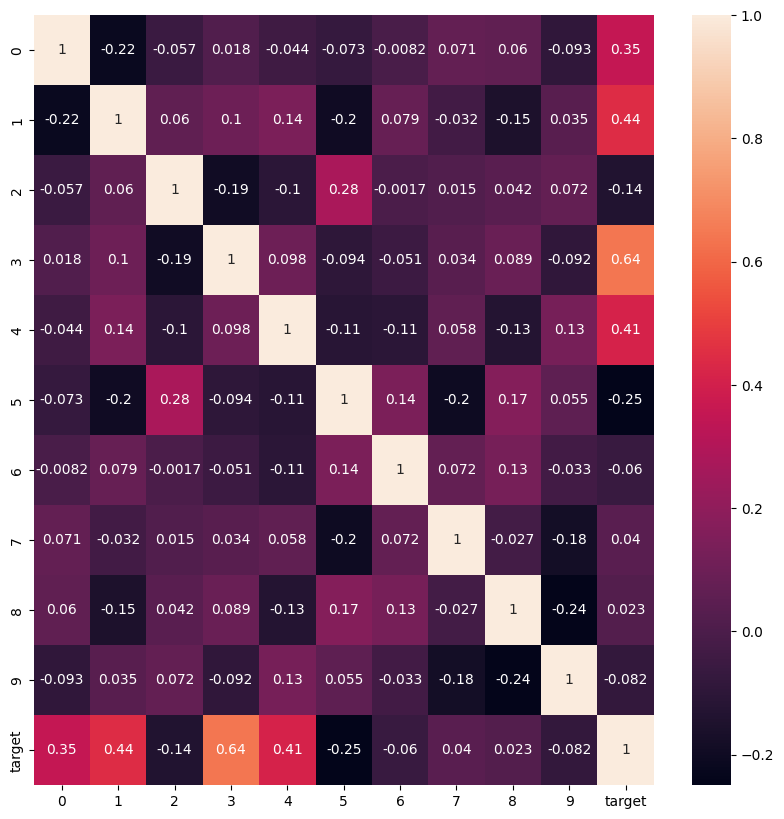

In [29]:
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(),annot=True)
plt.show()

Creating scatter plot for the data column over which target depends the most as seen clearly in the heatmap

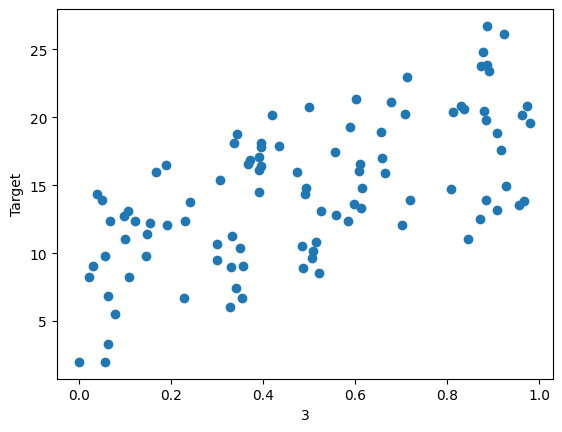

In [30]:
plt.scatter(data[3],data['target'])
plt.xlabel('3')
plt.ylabel('Target')
plt.show()

In [31]:
data.shape

(100, 11)

Spliting the data into training and testing set

In [32]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=2)
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(90, 10) (90,)
(10, 10) (10,)


In [33]:
scaler=StandardScaler()

Scaling the training and testing set

In [34]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

Model creation

In [35]:
model=LinearRegression()

Training the model

In [36]:
model.fit(X_train,y_train)

LinearRegression()

Prediction for the test data

In [37]:
y_pred=model.predict(X_test)

Mean squared error calculation

In [38]:
mse=mean_squared_error(y_test,y_pred)
print(mse)

3.7000207235085965


R^2 Calculation

In [39]:
r2=r2_score(y_test,y_pred)
print(r2)

0.7723699877875484


Plotting Actual vs Predicted values

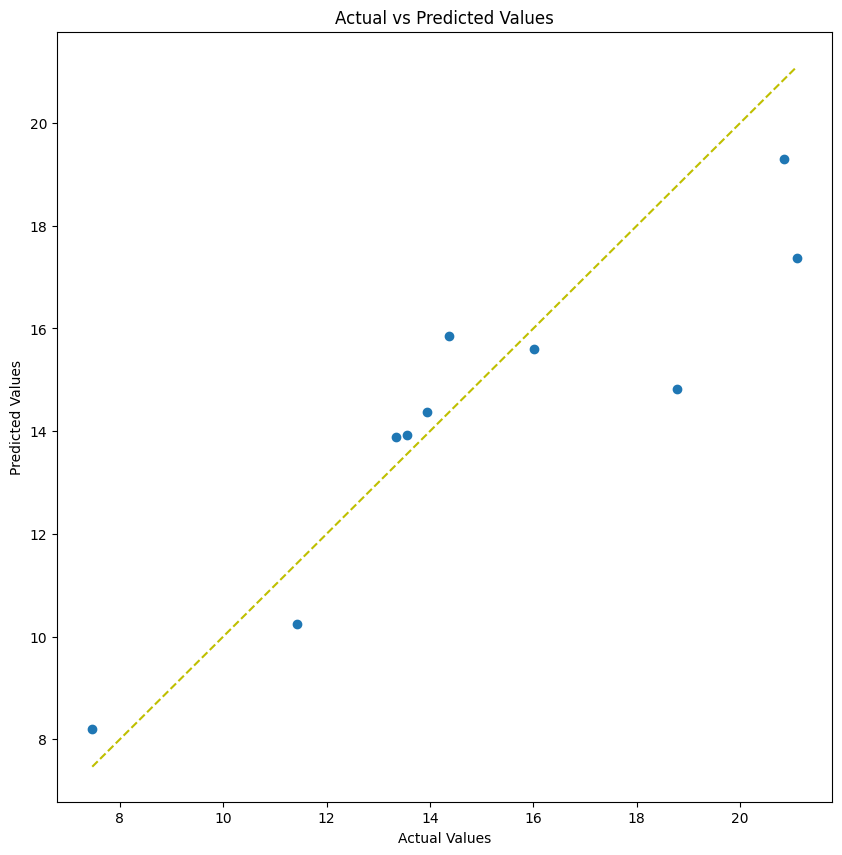

In [40]:
plt.figure(figsize=(10,10))
plt.scatter(y_test,y_pred)
plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],"y--"
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()